In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
warnings.filterwarnings("ignore")
import sys
sys.path.append('/home/future_commodity')
import os
import re
from pathlib import Path
from typing import List, Tuple

import numpy as np
np.seterr(all='ignore')
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from joblib import Parallel, delayed

import function_future.pre_train as pt
import function_future.train_model as tm
import function_future.FactorFilter as FF
import function_future.backtest_v3 as bv
import function_future.DataLoader as DL
import function_future.date_selection as DS
import function_future.trading_visualization as TV
from function_future.margin_calculator import calculate_margin, get_instrument_info, get_first_trade_date, get_recent_activity

In [3]:
symbol_lst = ["SR", "CF", "OI", "AP", "CJ", "PF", "PK", "RM"]

In [4]:
init_money_lst = []
for symbol in symbol_lst:
    margin = calculate_margin(symbol, 10)
    info = get_instrument_info(symbol)
    first_date = get_first_trade_date(symbol)
    activity = get_recent_activity(symbol)
    print(f"\n品种: {symbol} ({info.get('name', 'N/A')})")
    print(f"  首个交易日: {first_date}")
    print(f"  95分位数价格: {info['price_95th']:.2f}")
    print(f"  合约乘数: {info['contract_multiplier']}")
    print(f"  保证金率: {info['margin_rate']:.2%}")
    print(f"  10手保证金: {margin:,.2f}")
    print(f"  40%保证金所需本金: {margin / 0.4:,.0f} ")
    # print(f"  交易所: {info['exchange']}")
    print(f"  分均持仓量: {activity['avg_open_interest']:,.0f}")
    print(f"  分均成交量: {activity['avg_volume']:,.0f}")
    print(f"  分均成交额: {activity['avg_turnover']:,.0f}")

    init_money_lst.append(int(margin / 0.4))


品种: SR (白砂糖)
  首个交易日: 2021-02-01
  95分位数价格: 6063.00
  合约乘数: 10
  保证金率: 6.00%
  10手保证金: 36,378.00
  40%保证金所需本金: 90,945 
  分均持仓量: 369,957
  分均成交量: 663
  分均成交额: 36,988,125

品种: CF (棉花)
  首个交易日: 2021-02-01
  95分位数价格: 14885.00
  合约乘数: 5
  保证金率: 7.00%
  10手保证金: 52,097.50
  40%保证金所需本金: 130,244 
  分均持仓量: 590,983
  分均成交量: 815
  分均成交额: 57,040,952

品种: OI (菜籽油)
  首个交易日: 2021-02-01
  95分位数价格: 9985.00
  合约乘数: 10
  保证金率: 9.00%
  10手保证金: 89,865.00
  40%保证金所需本金: 224,662 
  分均持仓量: 261,760
  分均成交量: 893
  分均成交额: 85,021,866

品种: AP (苹果)
  首个交易日: 2021-02-01
  95分位数价格: 9731.00
  合约乘数: 10
  保证金率: 15.00%
  10手保证金: 145,965.00
  40%保证金所需本金: 364,912 
  分均持仓量: 107,286
  分均成交量: 443
  分均成交额: 38,083,192

品种: CJ (红枣)
  首个交易日: 2021-02-01
  95分位数价格: 11415.00
  合约乘数: 5
  保证金率: 10.00%
  10手保证金: 57,075.00
  40%保证金所需本金: 142,688 
  分均持仓量: 122,527
  分均成交量: 545
  分均成交额: 27,446,868

品种: PF (短纤)
  首个交易日: 2021-02-01
  95分位数价格: 6734.00
  合约乘数: 5
  保证金率: 7.00%
  10手保证金: 23,569.00
  40%保证金所需本金: 58,922 
  分均持仓量: 151,519
  分均成交量: 53

In [5]:
initial_capital = dict(zip(symbol_lst, init_money_lst))
initial_capital

{'SR': 90945,
 'CF': 130243,
 'OI': 224662,
 'AP': 364912,
 'CJ': 142687,
 'PF': 58922,
 'PK': 83100,
 'RM': 67675}

In [6]:
weights = dict(zip(symbol_lst, [5_000_000 // x for x in init_money_lst]))
weights

{'SR': 54,
 'CF': 38,
 'OI': 22,
 'AP': 13,
 'CJ': 35,
 'PF': 84,
 'PK': 60,
 'RM': 73}

In [7]:
train_label = 5
rtn_mul = 1

bt_params = (0.9, 0.5, 10, 5*345)
train_end_date = '2025-01-01'

In [8]:
def run_res(symbol, bt_params):
    folder_name = f'{symbol}_pred{train_label}_{train_end_date}_v0'

    config_loader = DL.InstrumentConfig()
    config_loader.get_instrument_config(symbol)

    config = bv.load_config(r"/mnt/Data/writable/liaoyuyang/backtest/backtest_config.json")
    config['MODEL_DIR'] = Path(config['MODEL_DIR']) / str(folder_name)

    bt = bv.ModelBacktester(train_end_date, config)
    bt.load_config(symbol)
    bt.window_end = '2027-01-01'
    bt.money = initial_capital[symbol]
    bt.fee = 0

    bt.load_factor(symbol, end_date=bt.window_end)
    bt.load_mktdata(symbol, end_date=bt.window_end)
    bt.load_models()
    bt.generate_predictions()
    pred = bt.combine_models('best_iteration_log_weighted', avg=True)

    th1, th2, holding_bars, day = bt_params
    merged_data = bt.backtest(th1=th1, th2=th2, save=False, open_drop=True, holding_bars=holding_bars,
                           day=day, model_name='best_iteration_log_weighted', v=2
                        )

    return merged_data

In [9]:
merged_data_lst = Parallel(n_jobs=len(symbol_lst))(delayed(run_res)(symbol, bt_params)
                                                   for symbol in symbol_lst)

trading_hours ['09:00-11:30', '13:30-15:00', '21:00-23:00']


  2%|▏         | 2420/102303 [00:07<05:41, 292.10it/s]

trading_hours ['09:00-11:30', '13:30-15:00']


 28%|██▊       | 29104/102303 [01:30<02:43, 446.88it/s]

trading_hours ['09:00-11:30', '13:30-15:00']


...

 98%|█████████▊| 62207/63448 [02:53<00:05, 247.23it/s]

trading_hours ['09:00-11:30', '13:30-15:00', '21:00-23:00']
trading_hours ['09:00-11:30', '13:30-15:00', '21:00-23:00']


  2%|▏         | 1599/96663 [00:04<04:03, 390.28it/s]]

trading_hours ['09:00-11:30', '13:30-15:00', '21:00-23:00']


100%|██████████| 96663/96663 [03:36<00:00, 445.52it/s]


In [10]:
def plot_all(symbol_lst, merged_data_lst, weights=None):
    pnl_ret = []
    for i, merged_data in enumerate(merged_data_lst):
        symbol = symbol_lst[i]
        df = merged_data.set_index('datetime')[['equity', 'date']]
        df.rename(columns={'equity':symbol}, inplace=True)
        df = df.groupby('date').last()
        # 如果有权重配置，应用权重
        if weights and symbol in weights:
            df[symbol] = df[symbol] * weights[symbol]

        # df = df.iloc[:-30]

        pnl_ret.append(df)

    return pd.concat(pnl_ret,axis=1).ffill().iloc[:-20]

In [11]:
merged_df_all = plot_all(symbol_lst, merged_data_lst, weights=weights)
merged_df_all

,SR,CF,OI,AP,CJ,PF,PK,RM
date,,,,,,,,
2025-01-02,5.037024e+06,4.996810e+06,5.244580e+06,4.800079e+06,4.947658e+06,5.127810e+06,5100495.561,4.955018e+06
2025-01-03,4.990902e+06,5.076673e+06,5.015011e+06,4.710923e+06,4.975655e+06,5.172469e+06,5183698.650,5.105255e+06
2025-01-06,4.969171e+06,5.067861e+06,5.135794e+06,4.875667e+06,5.070448e+06,5.178762e+06,5192803.833,5.224888e+06
2025-01-07,4.983623e+06,5.109768e+06,5.254017e+06,4.896196e+06,5.144761e+06,5.012084e+06,5212674.957,5.224004e+06
2025-01-08,4.943166e+06,5.255552e+06,5.351210e+06,4.757718e+06,5.089323e+06,5.201038e+06,5352371.736,5.210632e+06
...,...,...,...,...,...,...,...,...
2026-03-05,8.186315e+06,1.171409e+07,4.781339e+06,6.232478e+06,5.493361e+06,8.021562e+06,8290819.779,5.578766e+06
2026-03-06,8.242256e+06,1.165570e+07,4.786461e+06,6.251102e+06,5.611494e+06,7.739111e+06,8323932.384,5.653790e+06
2026-03-09,8.645953e+06,1.080202e+07,5.267684e+06,6.251102e+06,5.611494e+06,7.739111e+06,8323932.384,5.622324e+06


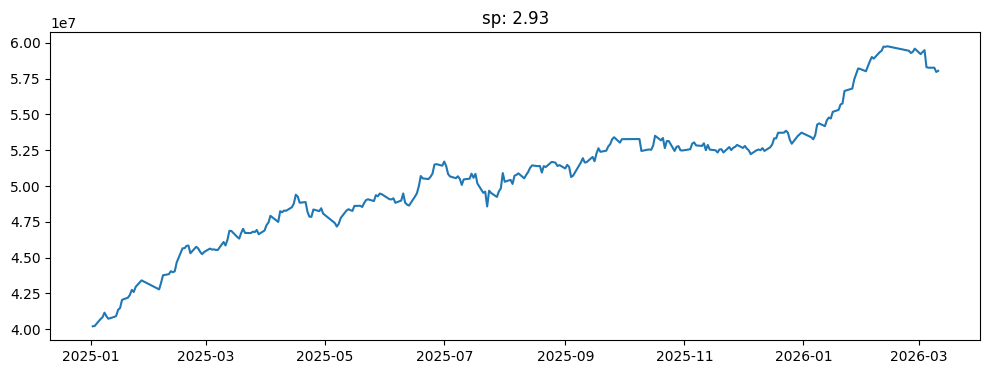

In [12]:
sp = merged_df_all.sum(axis=1).diff().mean() / merged_df_all.sum(axis=1).diff().std() * np.sqrt(252)
plt.figure(figsize=(12, 4))  # Correct way to set figure size
plt.plot(merged_df_all.sum(axis=1))
plt.title(f'sp: {round(sp,2)}')
plt.show()

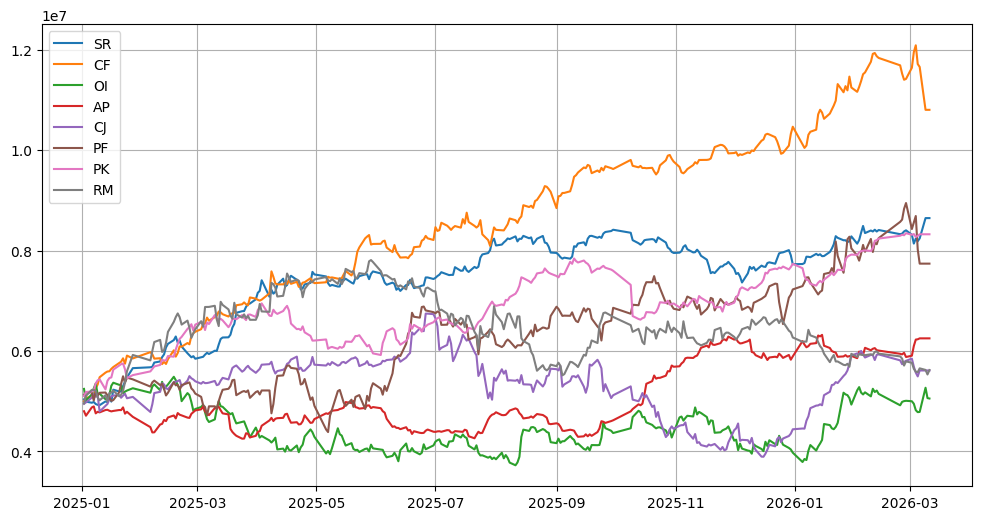

In [13]:
fig = plt.figure(figsize=(12, 6))
plt.plot(merged_df_all)
plt.legend(symbol_lst)
plt.grid()
plt.show()

In [14]:
res = pd.concat((bv.analyze_pos_distribution(merged_data_lst[i]) for i in range(len(symbol_lst))), axis=1)
res.columns = symbol_lst
res

,SR,CF,OI,AP,CJ,PF,PK,RM
多头(+1) 数量,21708,20340,19545,13257,11619,22625,12260,19388
空头(-1) 数量,18073,19607,19649,12917,13807,17244,14094,20524
空仓(0) 数量,56884,56718,64371,37276,38024,56787,37096,62393
多头占比,22.46%,21.04%,18.87%,20.89%,18.31%,23.41%,19.32%,18.95%
空头占比,18.70%,20.28%,18.97%,20.36%,21.76%,17.84%,22.21%,20.06%
空仓占比,58.85%,58.67%,62.16%,58.75%,59.93%,58.75%,58.46%,60.99%
交易日数量,284,284,306,282,282,284,282,302
总收益(非年化%),76.05,118.26,-15.54,31.77,12.36,56.36,66.95,12.05
总交易次数（开平算一次）,4049,4238,1916,1808,2807,3381,2829,2004
日均交易次数（开平算一次）,14.26,14.92,6.26,6.41,9.95,11.90,10.03,6.64
